![](https://www.freewpheaders.com/wp-content/gallery/planets-galaxies/earth-and-space-universe-header.jpg)

<p style="text-align:center;font-size:150%;font:serif;">
Welcome Aboard This Journey
</p>
<p style="text-align:center;font-size:150%;font:serif;">To help rescue crews and retrieve the lost passengers, you are challenged to predict which passengers were transported by the anomaly using records recovered from the spaceship’s damaged computer system.👩‍💻
</p>

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

plt.rcParams["figure.figsize"] = (15,7)

<p style="text-align:left;font-size:150%;font:serif;">
Read Data
</p>

In [2]:
# Read the training and testing data
df_train = pd.read_csv("../input/spaceship-titanic/train.csv")
df_test = pd.read_csv("../input/spaceship-titanic/test.csv")

In [3]:
# Let's display the training and testing data
display(df_train)
display(df_test)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


<p style="text-align:left;font-size:150%;font:serif;">
Exploratory Data Analysis
</p>

In [4]:
# Lets look at the feature data types 
display(df_train.dtypes)

PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

In [5]:
# Lets look at the descriptive statistics of train and test data
display(df_train.describe())
display(df_test.describe())

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,4186.000000,4195.000000,4171.000000,4179.000000,4176.000000,4197.000000
mean,28.658146,219.266269,439.484296,177.295525,303.052443,310.710031
std,14.179072,607.011289,1527.663045,560.821123,1117.186015,1246.994742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,53.000000,78.000000,33.000000,50.000000,36.000000
max,79.000000,11567.000000,25273.000000,8292.000000,19844.000000,22272.000000


<div class="alert alert-info" role="alert">
  As noticed from the previous tables the data distribution in the age column is almost normally distrbuted given that the mean is almost equal to the median.

However, in the other columns, the mean is much higher than the median which gives the indication that these columns are right skewed.

The skewness indicates that we have potential outliers. Let's investigate it.
</div>

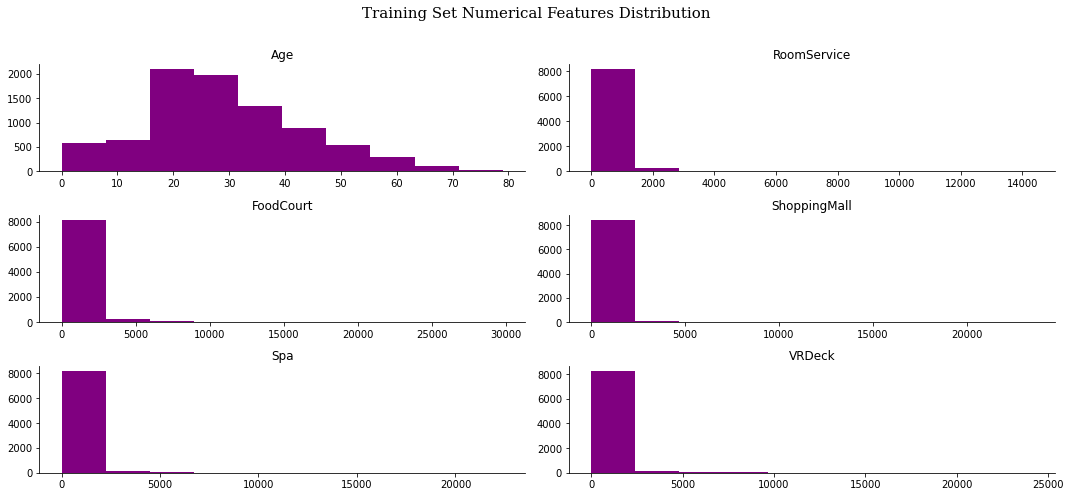

In [6]:
df_train.hist(column=["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"],
              sharex=False,
              sharey=False,
              color = 'purple',
              grid = False);  
plt.suptitle('Training Set Numerical Features Distribution\n', fontsize=15, font = 'serif');
plt.tight_layout()
sns.despine()

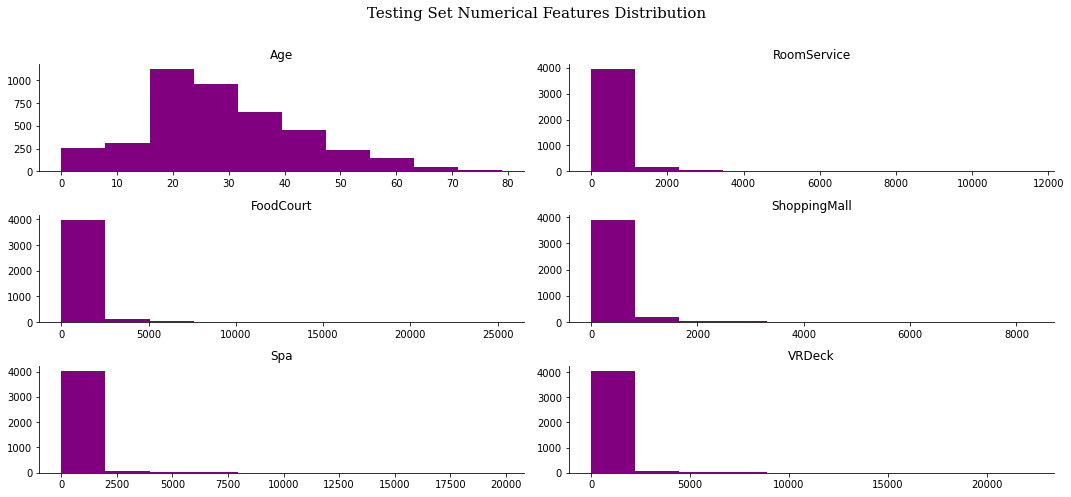

In [7]:
df_test.hist(column=["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"],
              sharex=False,
              sharey=False,
              color = 'purple',
             grid = False);  
plt.suptitle('Testing Set Numerical Features Distribution\n', fontsize=15, font = 'serif');
plt.tight_layout()
sns.despine()

<div class="alert alert-info" role="alert">
  Similar to our previous observation, the age column is a little right skewed but close to a normal distribution, however the other columns all are highly right skewed. Lets check if these outliers affect the probability of being transported to another dimension, if not I might consider dropping the highest outliers. I will investigate this further on.
</div>

<p style="text-align:left;font-size:120%;font:serif;">
Exploring Categorical Variables
</p>

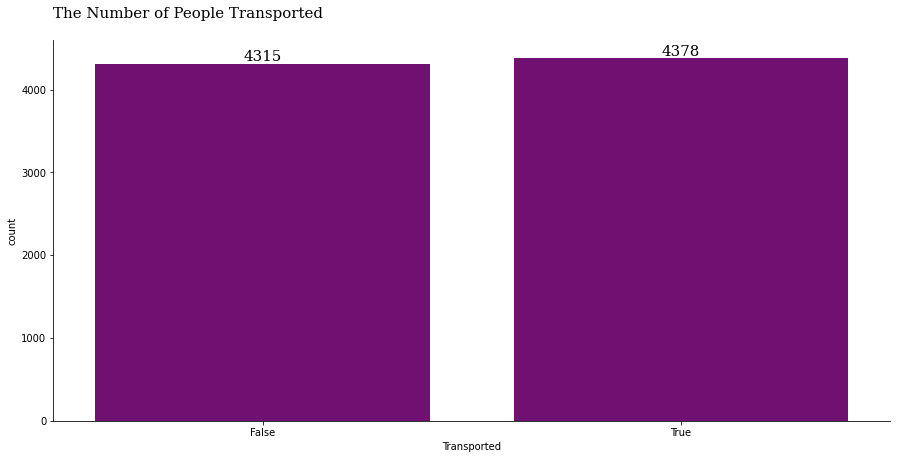

In [8]:
g = sns.countplot(x = df_train['Transported'], color = 'purple');
plt.title("The Number of People Transported\n", loc = 'left', size = 15, font = 'serif')
sns.despine()
g.bar_label(g.containers[0], size = 15, font = 'serif');

<div class="alert alert-info" role="alert">
It seems the class labels are balanced, with the true values being slightly higher than false.
</div>

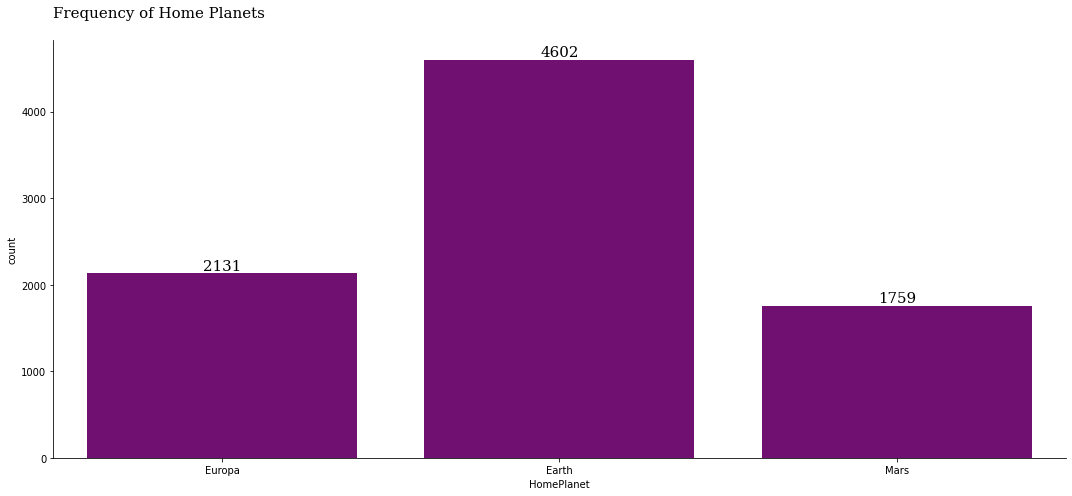

In [9]:
g = sns.countplot(data = df_train, x = "HomePlanet", color = 'purple') 
plt.title('Frequency of Home Planets\n', loc = 'left',fontsize=15, font = 'serif');
g.bar_label(g.containers[0], size = 15, font = 'serif');
plt.tight_layout()
sns.despine()

<div class="alert alert-info" role="alert">
It can be seen that passengers from planet Earth had the highest frequency of 4602, followed by Europa with frequency of 2131, and lastly Mars with frequency of 1759.
</div>

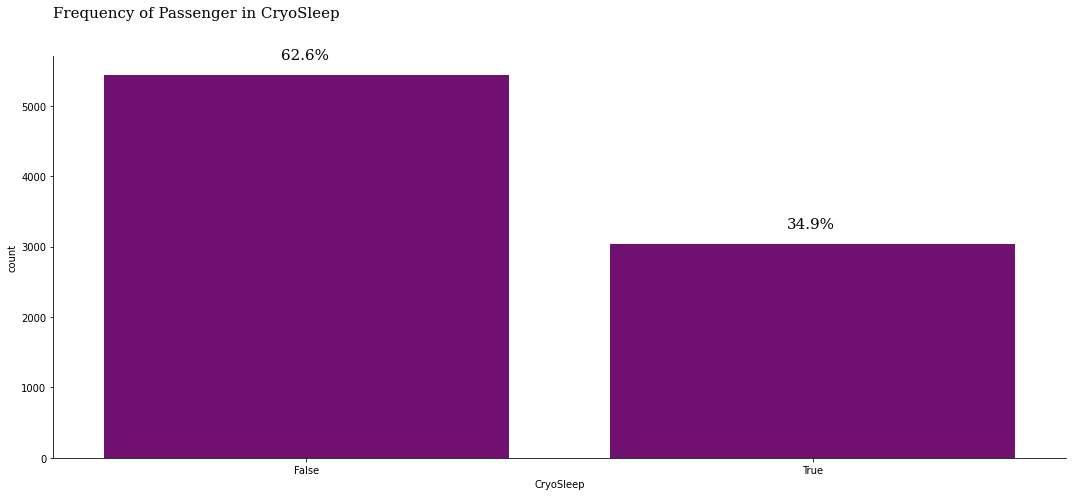

In [10]:
g = sns.countplot(data = df_train, x = "CryoSleep", color = 'purple')
plt.title('Frequency of Passenger in CryoSleep\n\n', loc = 'left',fontsize=15, font = 'serif');

def without_hue(ax, feature):
    total = len(feature)
    for p in ax.patches:
        percentage = '{:.1f}%\n'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = p.get_y() + p.get_height()
        ax.annotate(percentage, (x, y), size = 15, font = 'serif')

# g.bar_label(g.containers[0], size = 15, font = 'serif');
plt.tight_layout()
sns.despine()
without_hue(g, df_train.CryoSleep)

<div class="alert alert-info" role="alert">
As noticed from the previous graph 34.9% of passengers were in CryoSleep. As this is a big percentage I want to investigate later on if the passenger would be transported given that they were motionless in cryosleep.
</div>

In [11]:
# There is a high number of unique cabins so I will not plot it.
df_train.Cabin.nunique()

6560

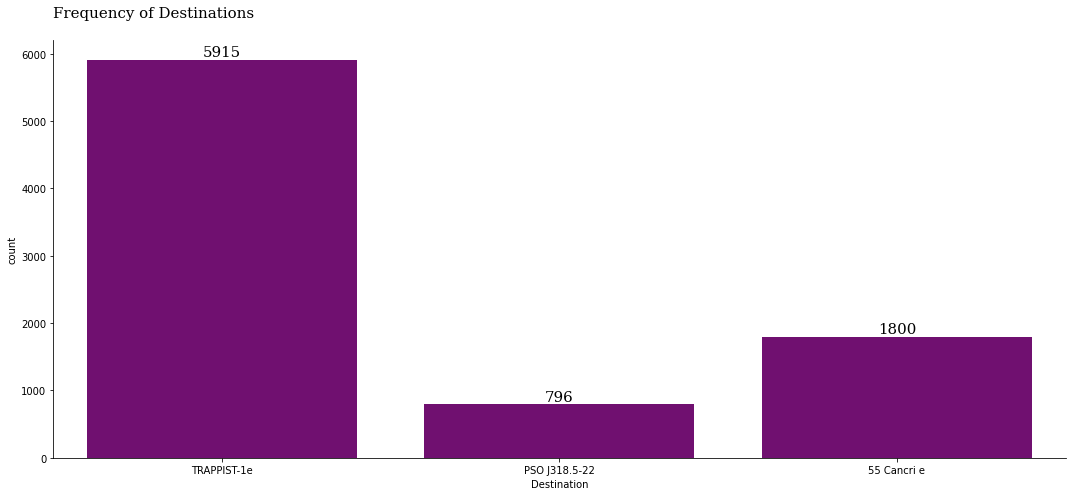

In [12]:
g = sns.countplot(x = df_train.Destination, color = 'purple')
plt.title('Frequency of Destinations\n', loc = 'left',fontsize=15, font = 'serif');
g.bar_label(g.containers[0], size = 15, font = 'serif');
plt.tight_layout()
sns.despine()

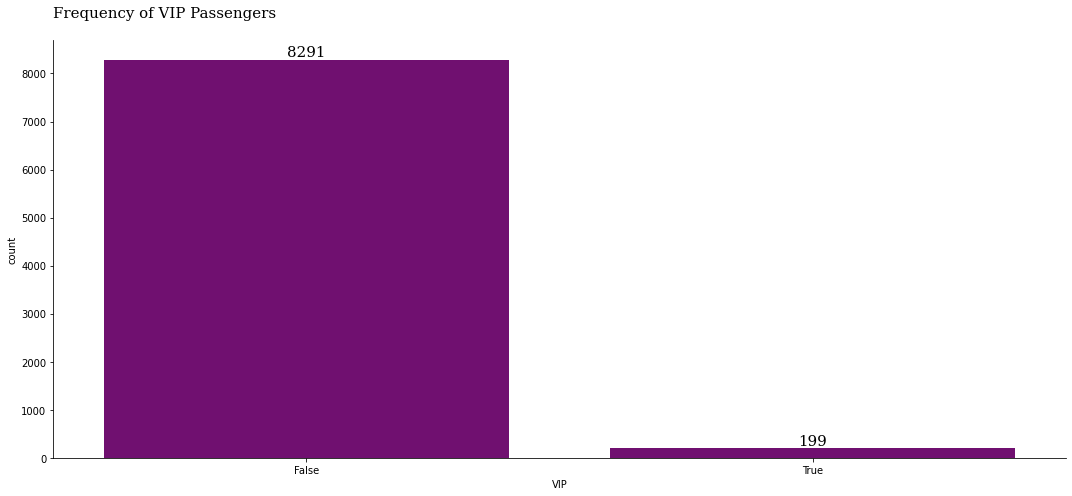

In [13]:
g = sns.countplot(x = df_train.VIP, color = 'purple')
plt.title('Frequency of VIP Passengers\n', loc = 'left',fontsize=15, font = 'serif');
g.bar_label(g.containers[0], size = 15, font = 'serif');
plt.tight_layout()
sns.despine()

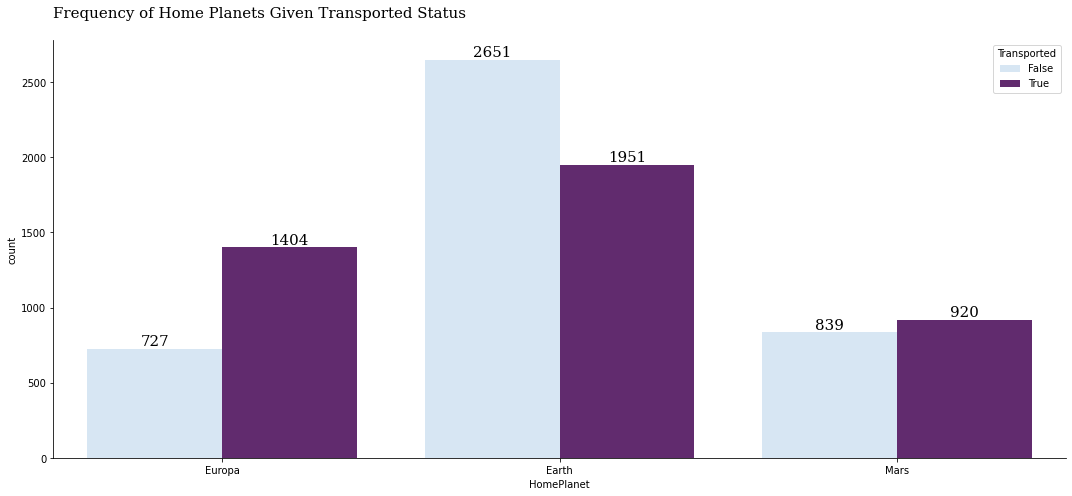

In [14]:
g = sns.countplot(data = df_train, x = "HomePlanet", hue = 'Transported',  palette = {True :'#682079', False:'#D3E7F7'},color = 'purple') 
plt.title('Frequency of Home Planets Given Transported Status\n', loc = 'left',fontsize=15, font = 'serif');
g.bar_label(g.containers[0], size = 15, font = 'serif');
g.bar_label(g.containers[1], size = 15, font = 'serif');
plt.tight_layout()
sns.despine()

In [15]:
(df_train[['HomePlanet', 'Transported']].value_counts(normalize = True)*100)

HomePlanet  Transported
Earth       False          31.217617
            True           22.974564
Europa      True           16.533208
Mars        True           10.833726
            False           9.879887
Europa      False           8.560999
dtype: float64

<div class="alert alert-info" role="alert">
From the previous plot we can see that passengers from Europa made up around 25% of total passengers and around 16.5% of them were transported. Passengers from Earth made up around 54% of total passengers and around 22% of them were transported. Lastly passengers from Mars made up around 20% of total passengers and 10.8% of them were transported. 

This shows that Europa passengers had the highest percentage of being transported.
</div>


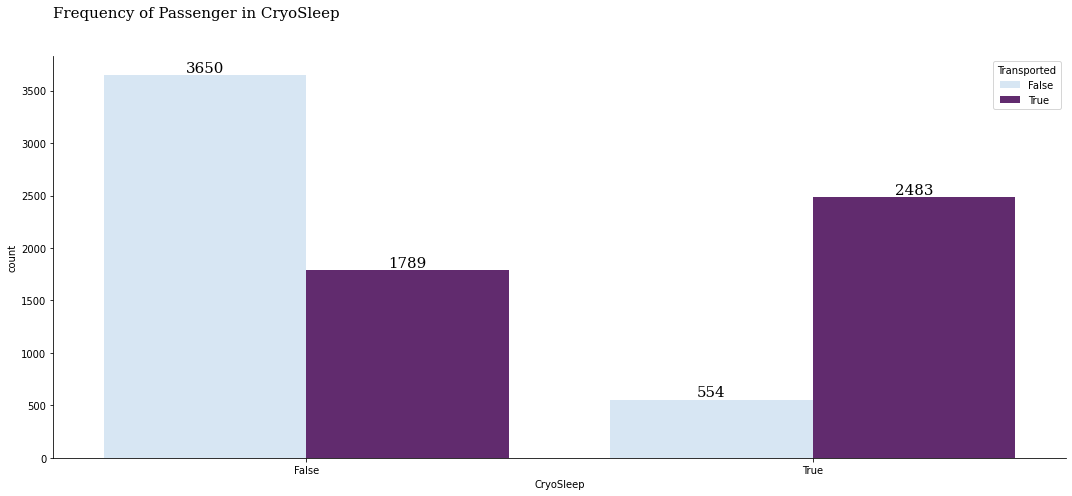

In [16]:
g = sns.countplot(data = df_train, x = "CryoSleep", color = 'purple', palette = {True :'#682079', False:'#D3E7F7'}, hue = 'Transported')
plt.title('Frequency of Passenger in CryoSleep\n\n', loc = 'left',fontsize=15, font = 'serif');

g.bar_label(g.containers[0], size = 15, font = 'serif');
g.bar_label(g.containers[1], size = 15, font = 'serif');
plt.tight_layout()
sns.despine()

In [17]:
(df_train[['CryoSleep', 'Transported']].value_counts(normalize = True)*100)

CryoSleep  Transported
False      False          43.062765
True       True           29.294479
False      True           21.106654
True       False           6.536102
dtype: float64

<div class="alert alert-info" role="alert">
Around 64% of passengers were not in CryoSleep and the majority of them around 43% were not transported. 

Around 36% of passengers were in CryoSleep and the majority of them around 29% were transported!

So it seems that being in CryoSleep is potential factor for being transported.
</div>

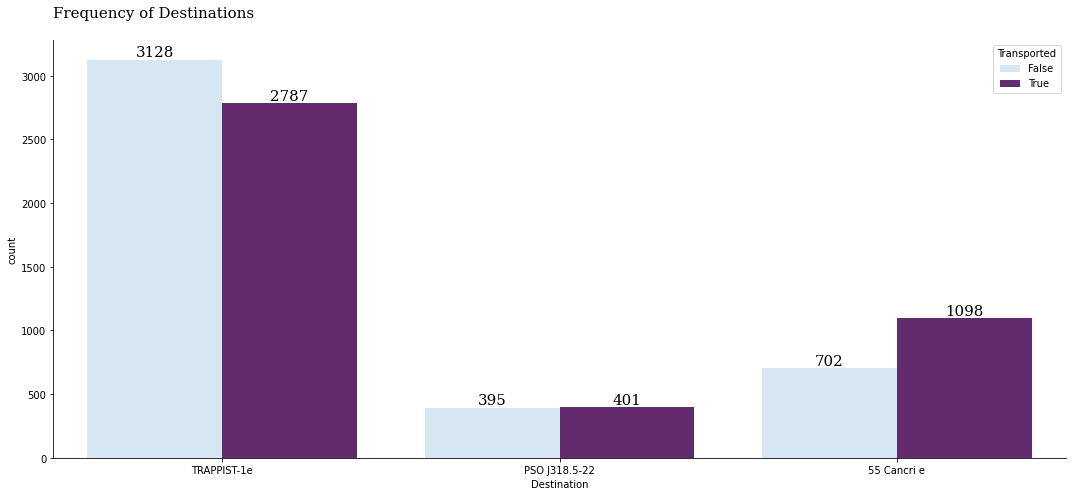

In [18]:
g = sns.countplot(data = df_train, x = 'Destination', color = 'purple',  palette = {True :'#682079', False:'#D3E7F7'},hue = 'Transported')
plt.title('Frequency of Destinations\n', loc = 'left',fontsize=15, font = 'serif');
g.bar_label(g.containers[0], size = 15, font = 'serif');
g.bar_label(g.containers[1], size = 15, font = 'serif');
plt.tight_layout()
sns.despine()

In [19]:
(df_train[['Destination', 'Transported']].value_counts(normalize = True)*100)

Destination    Transported
TRAPPIST-1e    False          36.752438
               True           32.745858
55 Cancri e    True           12.900952
               False           8.248149
PSO J318.5-22  True            4.711550
               False           4.641053
dtype: float64

<div class="alert alert-info" role="alert">
As noted in a previous plot, most passengers destination was TRAPPIST-1e. From around 69% of passengers destined to go to TRAPPIST-1e, 32.7% of them were transported. 

Out of around 20% of passengers going to 55 Cancri e, 13% of them were transported.

Almost half of the passengers going to PS0 J318.5-22 were transported.
</div>

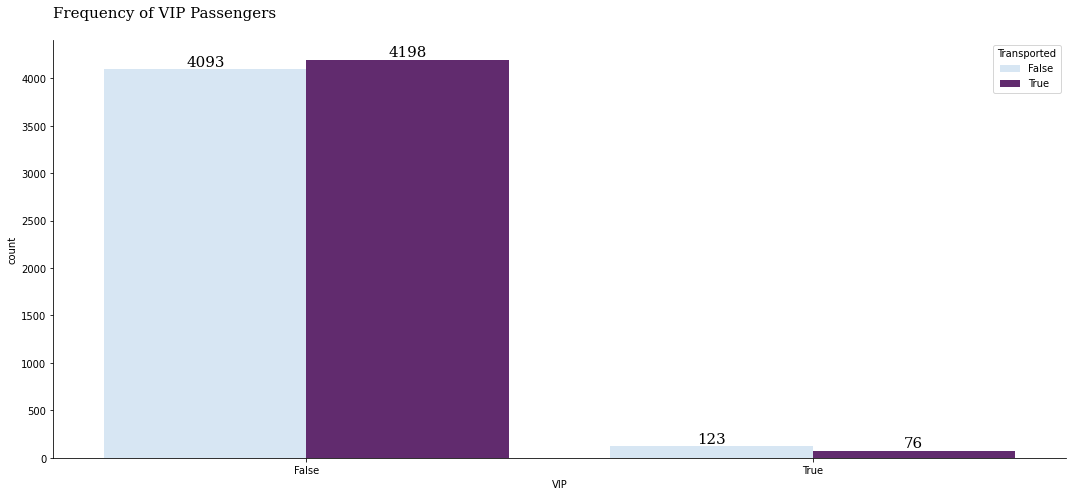

In [20]:
g = sns.countplot(x = df_train.VIP, color = 'purple', palette = {True :'#682079', False:'#D3E7F7'}, hue = df_train.Transported)
plt.title('Frequency of VIP Passengers\n', loc = 'left',fontsize=15, font = 'serif');
g.bar_label(g.containers[0], size = 15, font = 'serif');
g.bar_label(g.containers[1], size = 15, font = 'serif');
plt.tight_layout()
sns.despine()

In [21]:
(df_train[['VIP', 'Transported']].value_counts(normalize = True)*100)

VIP    Transported
False  True           49.446408
       False          48.209658
True   False           1.448763
       True            0.895171
dtype: float64

<div class="alert alert-info" role="alert">
Only around 2% of passengers were VIP and 0.9% of them were transported. I don't think VIP is a potential factor by itself to being transported or not. 
</div>

<p style="text-align:left;font-size:130%;font:serif;">
Exploring Numerical Variables
</p>

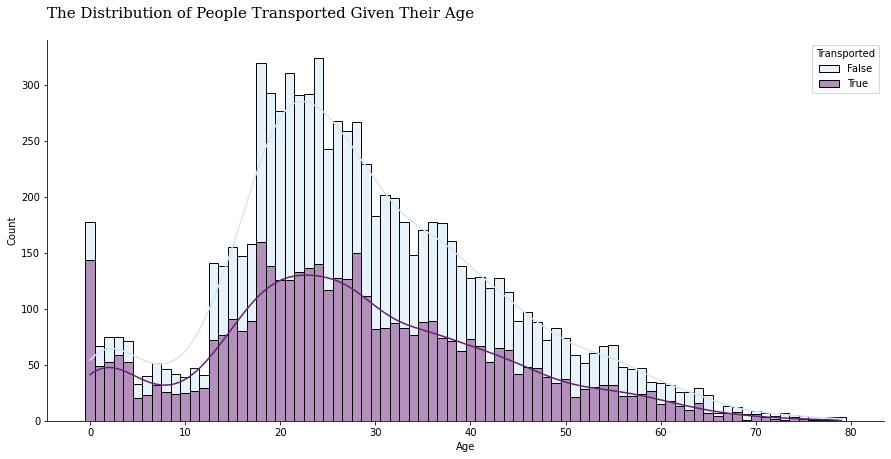

In [22]:
# A barplot on the count of transported given the numerical variables
g = sns.histplot(hue = df_train['Transported'], x = df_train['Age'],palette = {True :'#682079', False:'#D3E7F7'},discrete = True,kde = True, multiple = 'stack');
plt.title("The Distribution of People Transported Given Their Age\n", loc = 'left', size = 15, font = 'serif')
sns.despine()
# y_offset = -15
# # For each patch (basically each rectangle within the bar), add a label.
# for bar in g.patches:
#   g.text(
#       # Put the text in the middle of each bar. get_x returns the start
#       # so we add half the width to get to the middle.
#       bar.get_x() + bar.get_width() / 2,
#       # Vertically, add the height of the bar to the start of the bar,
#       # along with the offset.
#       bar.get_height() + bar.get_y() + y_offset,
#       # This is actual value we'll show.
#       round(bar.get_height()),
#       # Center the labels and style them a bit.
#       ha='center',
#       color='black',
#       weight='bold',
#       size=8
#   )

<div class="alert alert-info" role="alert">
Looking at people ages between 0 - 10, there are a higher percentage of transported than not transported.

People between ages 12 and 18, they also had a higher percentage of people transported than not transported.

From 18-26 more people weren't transported than transported, however the difference is quite small.
More people aged 28-30 were transported.

The counts varies with age there seems to be no specific pattern, but relatively it can be noticed that younger people were transported more than elders. Let's view the elders frequency above 60 more clearly below!
</div>

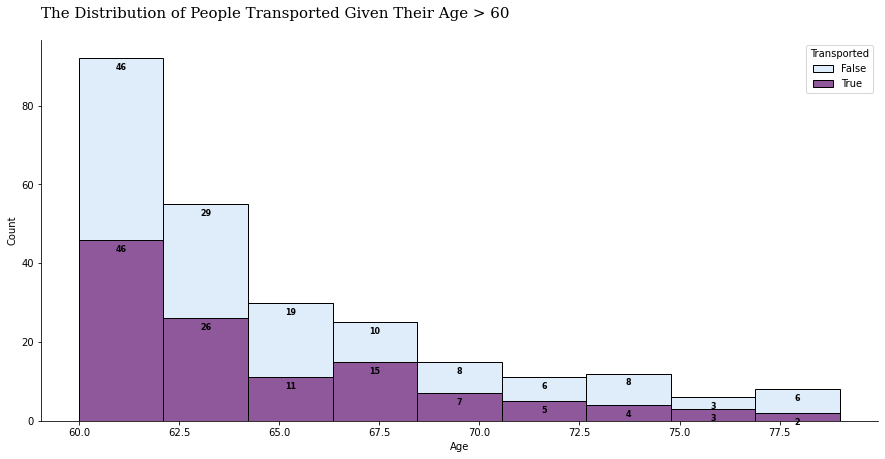

In [23]:
# A barplot on the count of transported given the numerical variables
g = sns.histplot(hue = df_train['Transported'], x = df_train['Age'].loc[df_train['Age'] >= 60],  palette = {True :'#682079', False:'#D3E7F7'}, multiple = 'stack');
plt.title("The Distribution of People Transported Given Their Age > 60\n", loc = 'left', size = 15, font = 'serif')
sns.despine()
y_offset = -3
# For each patch (basically each rectangle within the bar), add a label.
for bar in g.patches:
  g.text(
      # Put the text in the middle of each bar. get_x returns the start
      # so we add half the width to get to the middle.
      bar.get_x() + bar.get_width() / 2,
      # Vertically, add the height of the bar to the start of the bar,
      # along with the offset.
      bar.get_height() + bar.get_y() + y_offset,
      # This is actual value we'll show.
      round(bar.get_height()),
      # Center the labels and style them a bit.
      ha='center',
      color='black',
      weight='bold',
      size=8
  )

<div class="alert alert-info" role="alert">
People aged 60 were transported and not transported equally. However the frequency of people transported of older ages was less than people not transported except people aged around 67.5, 15 of them were transported compared with 10 who were not.
</div>

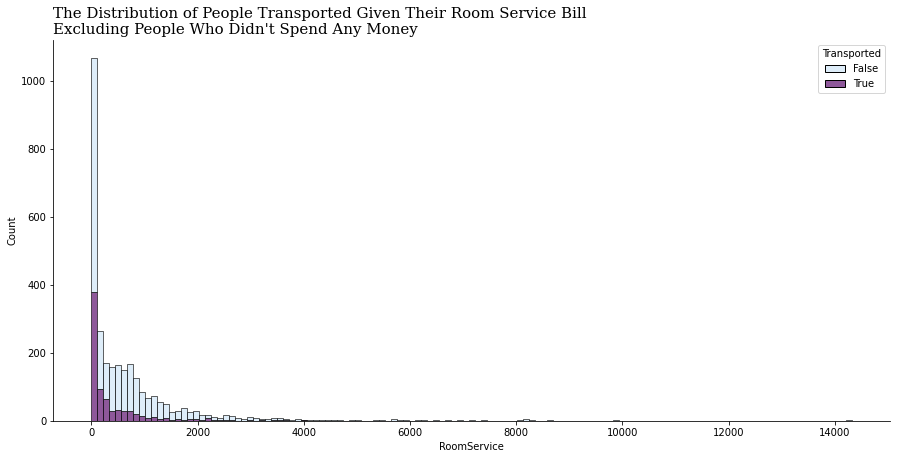

In [24]:
# A barplot on the count of transported given the numerical variables
df_train1 = df_train.loc[df_train['RoomService'] != 0]
g = sns.histplot(hue = df_train1['Transported'], x = df_train1['RoomService'],  palette = {True :'#682079', False:'#D3E7F7'}, multiple = 'stack');
plt.title("The Distribution of People Transported Given Their Room Service Bill\nExcluding People Who Didn't Spend Any Money", loc = 'left', size = 15, font = 'serif')
sns.despine()

In [25]:
df_train['RoomService'].max()

14327.0

<div class="alert alert-info" role="alert">
It can be noticed that the people who were billed the most for roomservice were less likely to be transported. To be able to see the pattern more apparently we need to deal with the outlier > 14000, but before that lets view the frequency of these outliers given their transported status.
</div>

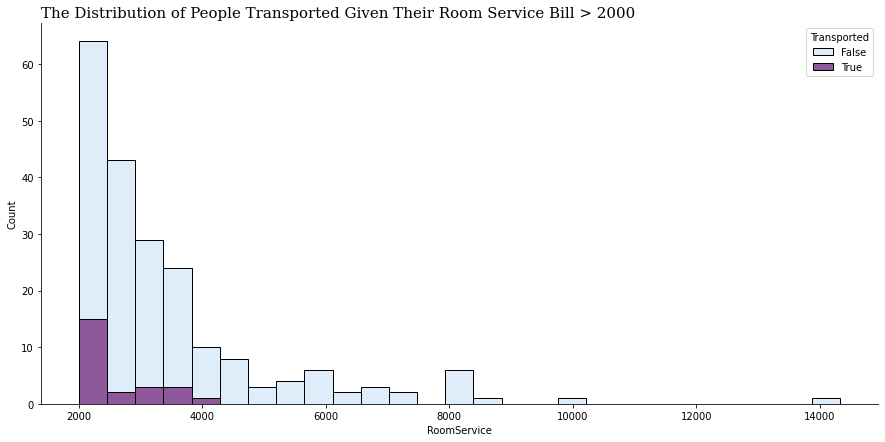

In [26]:
# A barplot on the count of transported given the numerical variables
df_train1 = df_train.loc[df_train['RoomService'] >= 2000]
g = sns.histplot(hue = df_train1['Transported'], x = df_train1['RoomService'], palette = {True :'#682079', False:'#D3E7F7'}, multiple = 'stack');
plt.title("The Distribution of People Transported Given Their Room Service Bill > 2000", loc = 'left', size = 15, font = 'serif')
sns.despine()

<div class="alert alert-info" role="alert">
It can be seen from the graph that people who paid > 4000 on room service were not transported! Which means that these outliers in RoomService are significant, hence I will not drop any of them.
</div>

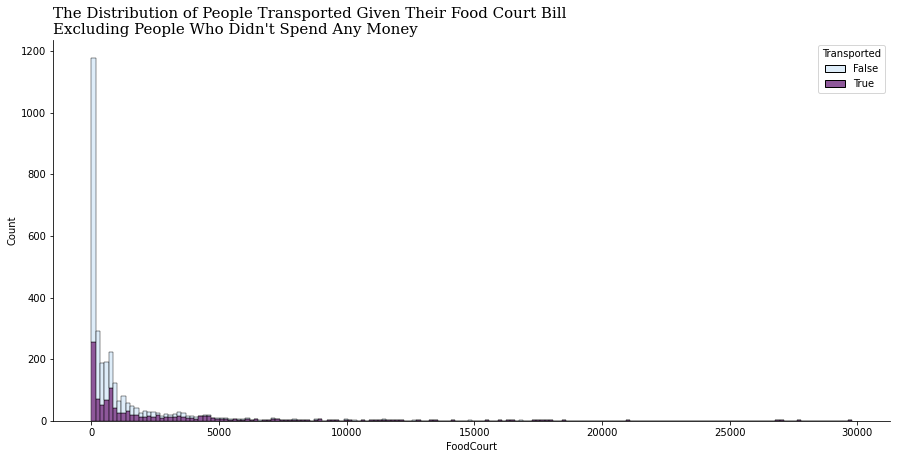

In [27]:
# A barplot on the count of transported given the numerical variables
df_train1 = df_train.loc[df_train['FoodCourt'] != 0]
g = sns.histplot(hue = df_train1['Transported'], x = df_train1['FoodCourt'],  palette = {True :'#682079', False:'#D3E7F7'}, multiple = 'stack');
plt.title("The Distribution of People Transported Given Their Food Court Bill\nExcluding People Who Didn't Spend Any Money", loc = 'left', size = 15, font = 'serif')
sns.despine()

<div class="alert alert-info" role="alert">
Unlike RoomService the higher the FoodCourt bill the more likely to be transported! Let's investigate this further.
</div>

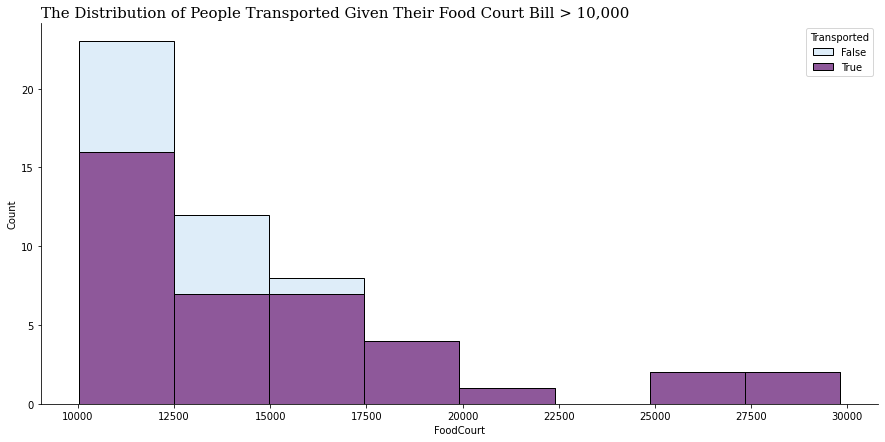

In [28]:
# A barplot on the count of transported given the numerical variables
df_train1 = df_train.loc[df_train['FoodCourt'] > 10000]
g = sns.histplot(hue = df_train1['Transported'], x = df_train1['FoodCourt'],  palette = {True :'#682079', False:'#D3E7F7'}, multiple = 'stack');
plt.title("The Distribution of People Transported Given Their Food Court Bill > 10,000", loc = 'left', size = 15, font = 'serif')
sns.despine()

<div class="alert alert-info" role="alert">
People who paid > 17500 were all transported!
</div>

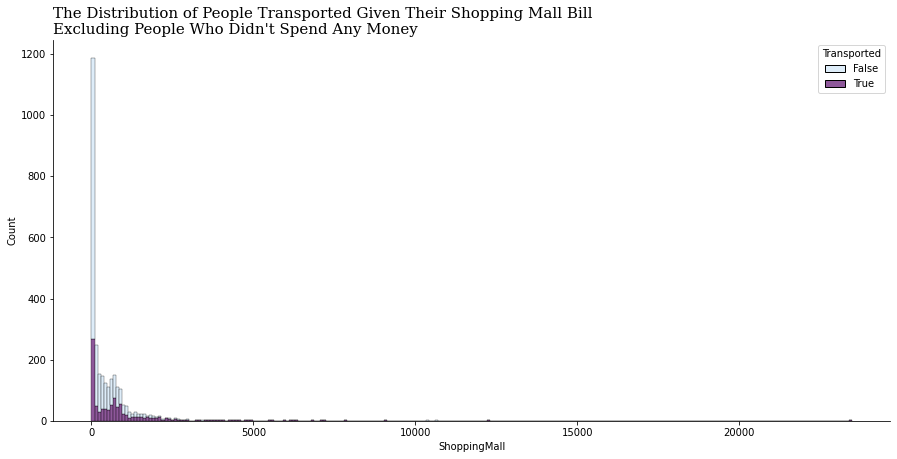

In [29]:
# A barplot on the count of transported given the numerical variables
df_train1 = df_train.loc[df_train['ShoppingMall'] != 0]
g = sns.histplot(hue = df_train1['Transported'], x = df_train1['ShoppingMall'],  palette = {True :'#682079', False:'#D3E7F7'}, multiple = 'stack');
plt.title("The Distribution of People Transported Given Their Shopping Mall Bill\nExcluding People Who Didn't Spend Any Money", loc = 'left', size = 15, font = 'serif')
sns.despine()

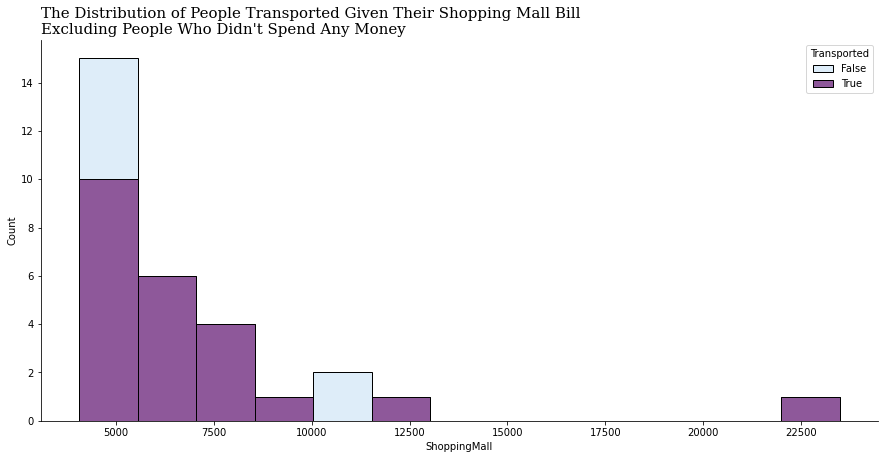

In [30]:
# A barplot on the count of transported given the numerical variables
df_train1 = df_train.loc[df_train['ShoppingMall'] > 4000]
g = sns.histplot(hue = df_train1['Transported'], x = df_train1['ShoppingMall'],  palette = {True :'#682079', False:'#D3E7F7'}, multiple = 'stack');
plt.title("The Distribution of People Transported Given Their Shopping Mall Bill\nExcluding People Who Didn't Spend Any Money", loc = 'left', size = 15, font = 'serif')
sns.despine()

<div class="alert alert-info" role="alert">
Similar to FoodCourt people who spent more money in ShoppingMall had higher frequency of being transported. However we can see an interesting point were 2 people who paid around 10,000 were not transported. 
</div>

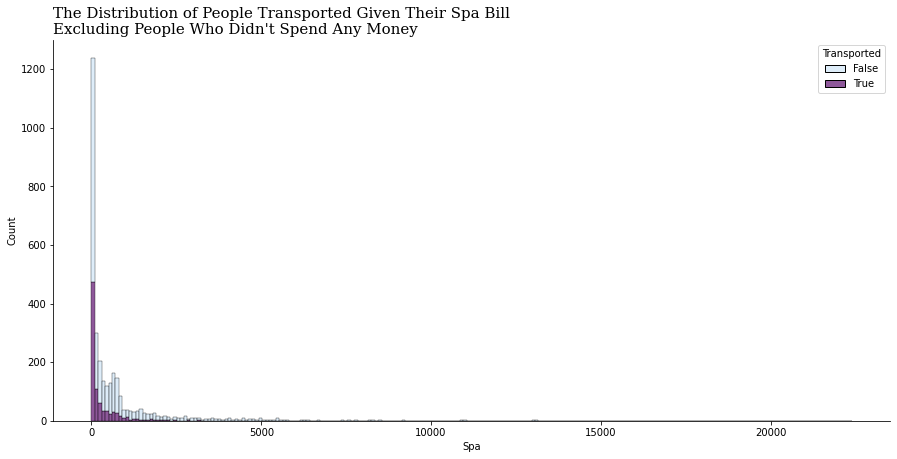

In [31]:
# A barplot on the count of transported given the numerical variables
df_train1 = df_train.loc[df_train['Spa'] != 0]
g = sns.histplot(hue = df_train1['Transported'], x = df_train1['Spa'],  palette = {True :'#682079', False:'#D3E7F7'}, multiple = 'stack');
plt.title("The Distribution of People Transported Given Their Spa Bill\nExcluding People Who Didn't Spend Any Money", loc = 'left', size = 15, font = 'serif')
sns.despine()

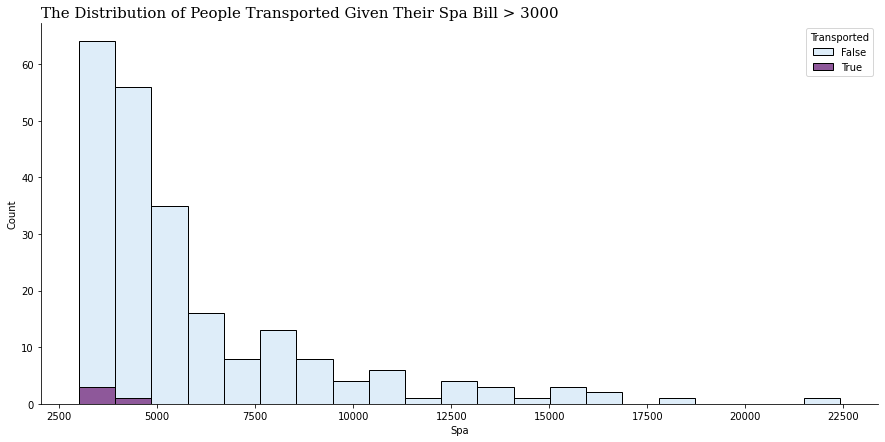

In [32]:
# A barplot on the count of transported given the numerical variables
df_train1 = df_train.loc[df_train['Spa'] >= 3000]
g = sns.histplot(hue = df_train1['Transported'], x = df_train1['Spa'],  palette = {True :'#682079', False:'#D3E7F7'}, multiple = 'stack');
plt.title("The Distribution of People Transported Given Their Spa Bill > 3000", loc = 'left', size = 15, font = 'serif')
sns.despine()

<div class="alert alert-info" role="alert">
Apparently the higher people spent on Spa the less frequently they were transported to the alternate dimension.
</div>

<div class="alert alert-info" role="alert">
The pattern here could be that the more someone spend money in a place the more likely they are to frequent that particular place so for example people who spent most of their time in a less populated area like Spa or their rooms they were less frequently transported or not transported at all. Unlike if they spent all of their time/money in a highly populated area like FoodCourt or ShoppingMall the frequency of the people transported was higher. Lets see if our assumption also applies on VRDeck which I assume to be less populated area.
</div>


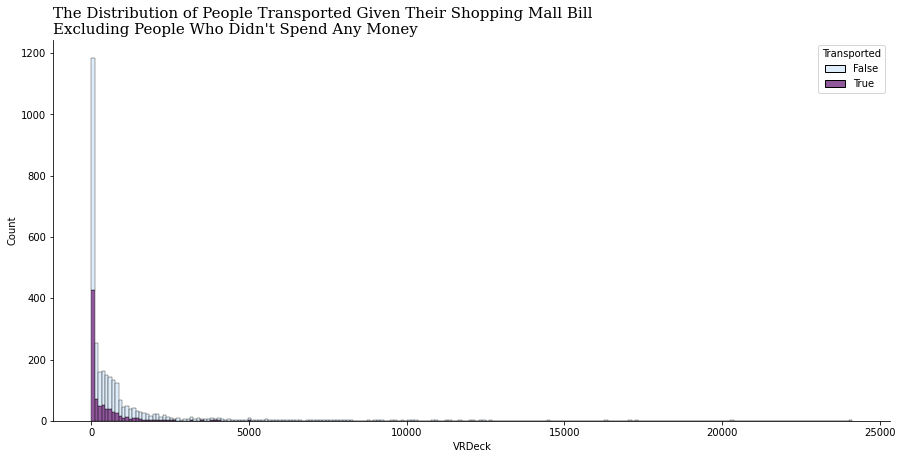

In [33]:
# A barplot on the count of transported given the numerical variables
df_train1 = df_train.loc[df_train['VRDeck'] != 0]
g = sns.histplot(hue = df_train1['Transported'], x = df_train1['VRDeck'],  palette = {True :'#682079', False:'#D3E7F7'}, multiple = 'stack');
plt.title("The Distribution of People Transported Given Their Shopping Mall Bill\nExcluding People Who Didn't Spend Any Money", loc = 'left', size = 15, font = 'serif')
sns.despine()

<div class="alert alert-info" role="alert">
It appears that the more you spend in VRDeck the less likely you are to be transported! Let's have a deeper look!</div>

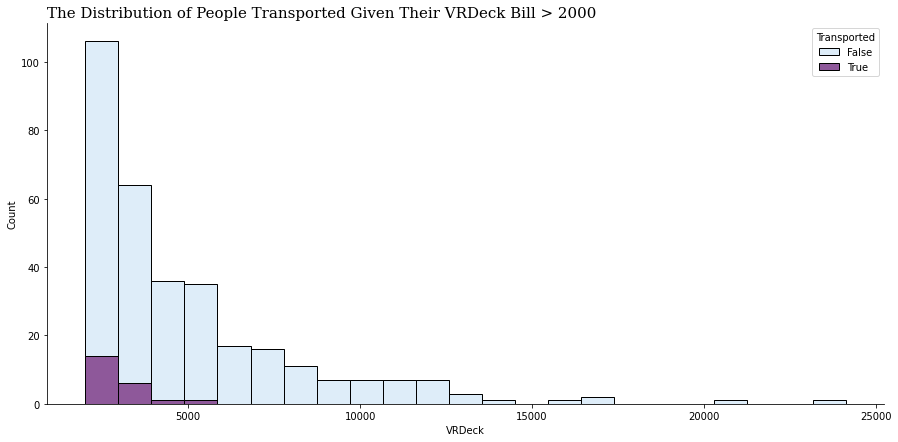

In [34]:
# A barplot on the count of transported given the numerical variables
df_train1 = df_train.loc[df_train['VRDeck'] > 2000]
g = sns.histplot(hue = df_train1['Transported'], x = df_train1['VRDeck'],  palette = {True :'#682079', False:'#D3E7F7'}, multiple = 'stack');
plt.title("The Distribution of People Transported Given Their VRDeck Bill > 2000", loc = 'left', size = 15, font = 'serif')
sns.despine()

<div class="alert alert-info" role="alert">
People who spent more than 6000 in the VRDeck were not transported at all compared with people who spent much lower. This matched my previous assumption, let's keep going!
</div>

In [35]:
# Lets clean the data
display(df_train.isnull().sum())

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [36]:
# # Let's visualize the outliers

# sns.pairplot(df_train[["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]]);  
# plt.suptitle('Training Set Numerical Bivariate Distribution\n', fontsize=15, font = 'serif');
# plt.tight_layout()
# sns.despine()

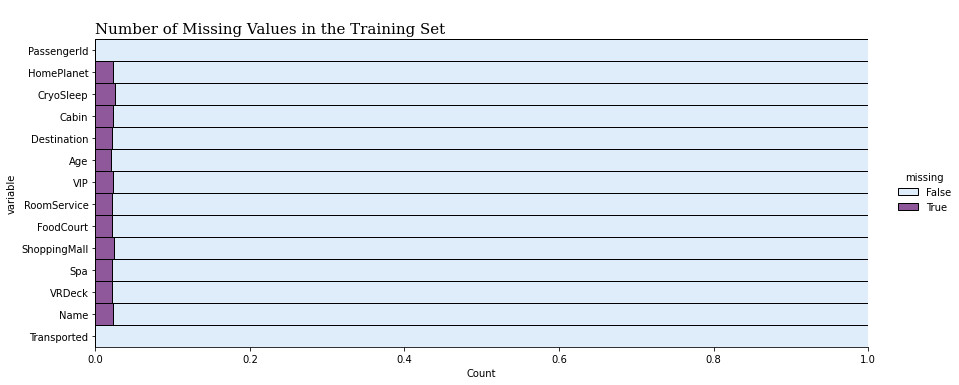

In [37]:
sns.displot(
    data=df_train.isna().melt(value_name="missing"),
    y="variable",
    hue="missing",
    multiple="fill",
    palette = {True :'#682079', False:'#D3E7F7'},
    aspect=2.5,
);
sns.despine();
plt.title("\nNumber of Missing Values in the Training Set", font = 'serif', loc = 'left', size = 15);


<div class="alert alert-info" role="alert">
All columns except Passenger ID and Transported seem to have missing values.

Columns all appear to have similar percentages of missing values however the highest are CrypSleep, VIP, ShoppingMall, and Name.
</div>

In [38]:
display(df_test.isnull().sum())

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

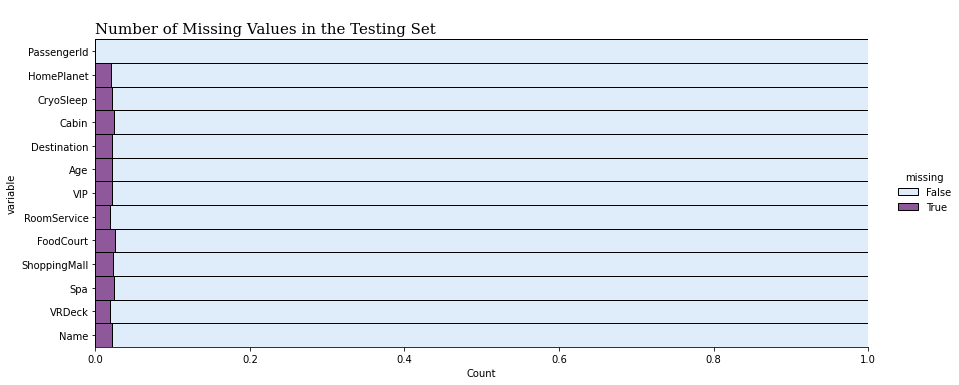

In [39]:
sns.displot(
    data=df_test.isna().melt(value_name="missing"),
    y="variable",
    hue="missing",
    multiple="fill",
    palette = {True :'#682079', False:'#D3E7F7'},
    aspect=2.5,
);
sns.despine();
plt.title("\nNumber of Missing Values in the Testing Set", font = 'serif', loc = 'left', size = 15);


<div class="alert alert-info" role="alert">
Similarily to the training data, there are no nulls in the passengerID and the rest of the columns have missing values in similar percentages to the training data. 

However columns with most missing values appear to be Cabin, FoodCourt and Spa.
</div>

<p style="text-align:left;font-size:150%;font:serif;">
Data Cleaning
</p>

In [40]:
#Lets drop all nulls initially
df_train = df_train.dropna()

In [41]:
# There appears to be no duplicated data
df_train.duplicated().sum()

0

In [42]:
# Lets drop passengerID column initially
df_train['Transported'].replace({False: 0, True: 1}, inplace = True)
df_train.drop(['PassengerId', 'Name', 'Cabin'], axis = 1, inplace = True)
df_test.drop(['PassengerId', 'Name',  'Cabin'], axis = 1, inplace = True)

In [43]:
# Onehot encoder
df_train = pd.get_dummies(df_train)
display(df_train.head())

df_test = pd.get_dummies(df_test)
display(df_test.head())

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_False,CryoSleep_True,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_False,VIP_True
0,39.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,1,0,0,0,1,1,0
1,24.0,109.0,9.0,25.0,549.0,44.0,1,1,0,0,1,0,0,0,1,1,0
2,58.0,43.0,3576.0,0.0,6715.0,49.0,0,0,1,0,1,0,0,0,1,0,1
3,33.0,0.0,1283.0,371.0,3329.0,193.0,0,0,1,0,1,0,0,0,1,1,0
4,16.0,303.0,70.0,151.0,565.0,2.0,1,1,0,0,1,0,0,0,1,1,0


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_False,CryoSleep_True,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_False,VIP_True
0,27.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,1,0,0,1,1,0
1,19.0,0.0,9.0,0.0,2823.0,0.0,1,0,0,1,0,0,0,1,1,0
2,31.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,1,1,0,0,1,0
3,38.0,0.0,6652.0,0.0,181.0,585.0,0,1,0,1,0,0,0,1,1,0
4,20.0,10.0,0.0,635.0,0.0,0.0,1,0,0,1,0,0,0,1,1,0


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(df_train.drop('Transported', axis = 1), df_train['Transported'], test_size=0.2, random_state=0)

<p style="text-align:left;font-size:150%;font:serif;">
CatBoost Classifier</p>

<div class="alert alert-info" role="alert">
Classification accuracy is a metric that summarizes the performance of a classification model as the number of correct predictions divided by the total number of predictions.
</div>

In [45]:
from catboost import CatBoostClassifier

clf = CatBoostClassifier(
    iterations=5, 
    learning_rate=0.1, 
    loss_function='Logloss', eval_metric = 'Accuracy'
)

clf.fit(X_train, y_train, 
        eval_set=(X_val, y_val)
)

print(clf.get_best_score())

0:	learn: 0.7657078	test: 0.7632375	best: 0.7632375 (0)	total: 54.1ms	remaining: 217ms
1:	learn: 0.7736563	test: 0.7662632	best: 0.7662632 (1)	total: 57.3ms	remaining: 86ms
2:	learn: 0.7768736	test: 0.7677761	best: 0.7677761 (2)	total: 60.1ms	remaining: 40.1ms
3:	learn: 0.7772521	test: 0.7670197	best: 0.7677761 (2)	total: 62.9ms	remaining: 15.7ms
4:	learn: 0.7852006	test: 0.7760968	best: 0.7760968 (4)	total: 65.3ms	remaining: 0us

bestTest = 0.776096823
bestIteration = 4

{'learn': {'Accuracy': 0.7852006056018168, 'Logloss': 0.5715692174042522}, 'validation': {'Accuracy': 0.7760968229954615, 'Logloss': 0.5723826081069883}}


In [46]:
y = clf.predict(df_test)

In [47]:
sample = pd.read_csv("../input/spaceship-titanic/sample_submission.csv")
sample

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False
...,...,...
4272,9266_02,False
4273,9269_01,False
4274,9271_01,False
4275,9273_01,False


In [48]:
sample['Transported'] = y
sample['Transported'].replace({0: False, 1: True}, inplace = True)
sample.to_csv("new1", index = False)

<p style="text-align:center;font-size:150%;font:serif;">Thank you for reading! Would love to hear any edits or suggestions!</p>